In [1]:

import xarray as xr
from xgcm.grid import Grid
import xgcm
from typing import Annotated
from dask.diagnostics import ProgressBar
from matplotlib.colors import BoundaryNorm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
def open_llc4320_velocity_data(chunks='auto', time_range=None):
    
    ds_SSU = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssu", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    ds_SSV = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/ssv", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )

    ds_Theta = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/sst", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    # Open grid data
    ds_grid = xr.open_dataset(
        "gs://pangeo-ecco-llc4320/grid", 
        engine="zarr", 
        storage_options={'requester_pays': True}, 
        chunks=chunks, 
        inline_array=True,
        consolidated=True, 
    )
    
    coords_to_keep = ['XC', 'YC','XG','YG', 'dxC', 'dyC', 'dxG', 'dyG', 'rAz', 'rA', 'Depth']
    ds_grid = ds_grid.reset_coords()[coords_to_keep]
    
    ds = xr.merge([ds_SSU, ds_SSV, ds_Theta, ds_grid])
        
    if time_range is not None:
        ds = ds.isel(time=time_range)
        
    ds = ds.chunk(chunks)
    
    return ds, ds_grid
    

In [3]:



@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def vort(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
    raz: Annotated[np.ndarray, "(Y:left,X:left)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    """Dimensional vorticity"""
    
    u_trans = u * dxc
    v_trans = v * dyc
    v_diff_x = v_trans[..., 1:, 1:] - v_trans[..., 1:, :-1]
    u_diff_y = u_trans[..., 1:, 1:] - u_trans[..., :-1, 1:]
    return (v_diff_x - u_diff_y) / raz[..., 1:, 1:]

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",    
)
def strain(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxc: Annotated[np.ndarray, "(Y:center,X:left)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyc: Annotated[np.ndarray, "(Y:left,X:center)"],
) ->     Annotated[np.ndarray, "(Y:left,X:left)"]:
    u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
    v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
    u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_x_trimmed = v_diff_x[..., 1:, :]
    u_diff_y_trimmed = u_diff_y[..., 1:]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    strain_normal = u_diff_x_trimmed - v_diff_y_trimmed
    strain_shear = v_diff_x_trimmed + u_diff_y_trimmed
    
    # TODO: interpolate the shear strain onto the positions of the normal strain
    # For now, we just pretend they are at the same grid point
    strain_mag = np.sqrt(strain_normal ** 2 +  strain_shear ** 2)
    
    return strain_mag

@xgcm.as_grid_ufunc(
    boundary_width={"X": (1, 0), "Y": (1, 0)},
    boundary="fill",
    fill_value=np.nan,
    dask="parallelized",
)
def divergence(
    u:   Annotated[np.ndarray, "(Y:center,X:left)"],
    dxg: Annotated[np.ndarray, "(Y:left,X:center)"],
    v:   Annotated[np.ndarray, "(Y:left,X:center)"],
    dyg: Annotated[np.ndarray, "(Y:center,X:left)"],
    ra:  Annotated[np.ndarray, "(Y:center,X:center)"],
) ->     Annotated[np.ndarray, "(Y:center,X:center)"]:
    
    u_diff_x = (u[..., 1:] - u[..., :-1]) * dxg[..., 1:]
    v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) * dyg[..., 1:, :]
    
    u_diff_x_trimmed = u_diff_x[..., 1:, :]
    v_diff_y_trimmed = v_diff_y[..., 1:]
    
    divergence = (u_diff_x_trimmed + v_diff_y_trimmed) / ra[..., 1:, 1:]
    
    return divergence

In [4]:
ds, ds_grid = open_llc4320_velocity_data(chunks={})

In [5]:
grid = Grid(ds_grid, periodic=False)

In [6]:
t_width=240
i_eq = slice(0,540)
j_eq = slice(3780,4320)
ds_eq = ds.isel(time=slice(8500-t_width,8500+t_width)).sel(face=1
                                ).isel(j_g=j_eq).isel(j=j_eq).isel(i_g=i_eq).isel(i=i_eq)

t_width=240
i_sum = slice(1620,2160)
j_sum = slice(3780,4320)
ds_sum = ds.isel(time=slice(4500-t_width,4500+t_width)).sel(face=8
                                ).isel(j_g=j_sum).isel(j=j_sum).isel(i_g=i_sum).isel(i=i_sum)
depth_sum = ds_grid.Depth.sel(face=8).isel(j=j_sum).isel(i=i_sum)

t_width=240
i_gs = slice(2700,3240)
j_gs = slice(2700,3240)
ds_gs = ds.isel(time=slice(8500-t_width,8500+t_width)).sel(face=10
                                ).isel(j_g=j_gs).isel(j=j_gs).isel(i_g=i_gs).isel(i=i_gs)



In [8]:
ds.dxC

<xarray.DataArray 'dxC' (face: 13, j: 4320, i_g: 4320)> Size: 970MB
dask.array<open_dataset-dxC, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 4320, 4320), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i_g      (i_g) int64 35kB 0 1 2 3 4 5 6 ... 4314 4315 4316 4317 4318 4319
Attributes:
    coordinate:     YC XG
    long_name:      cell x size
    standard_name:  cell_x_size_at_u_location
    units:          m

In [7]:
ζ = vort(grid, ds.U, ds.dxC, ds.V, ds.dyC, ds.rAz, axis= 5 * [("Y", "X")])
σ = strain(grid, ds.U, ds.dxC, ds.V, ds.dyC, axis=4 * [("Y", "X")])
D = divergence(grid, ds.U, ds.dxG, ds.V, ds.dyG, ds.rA, axis= 5 * [("Y", "X")])

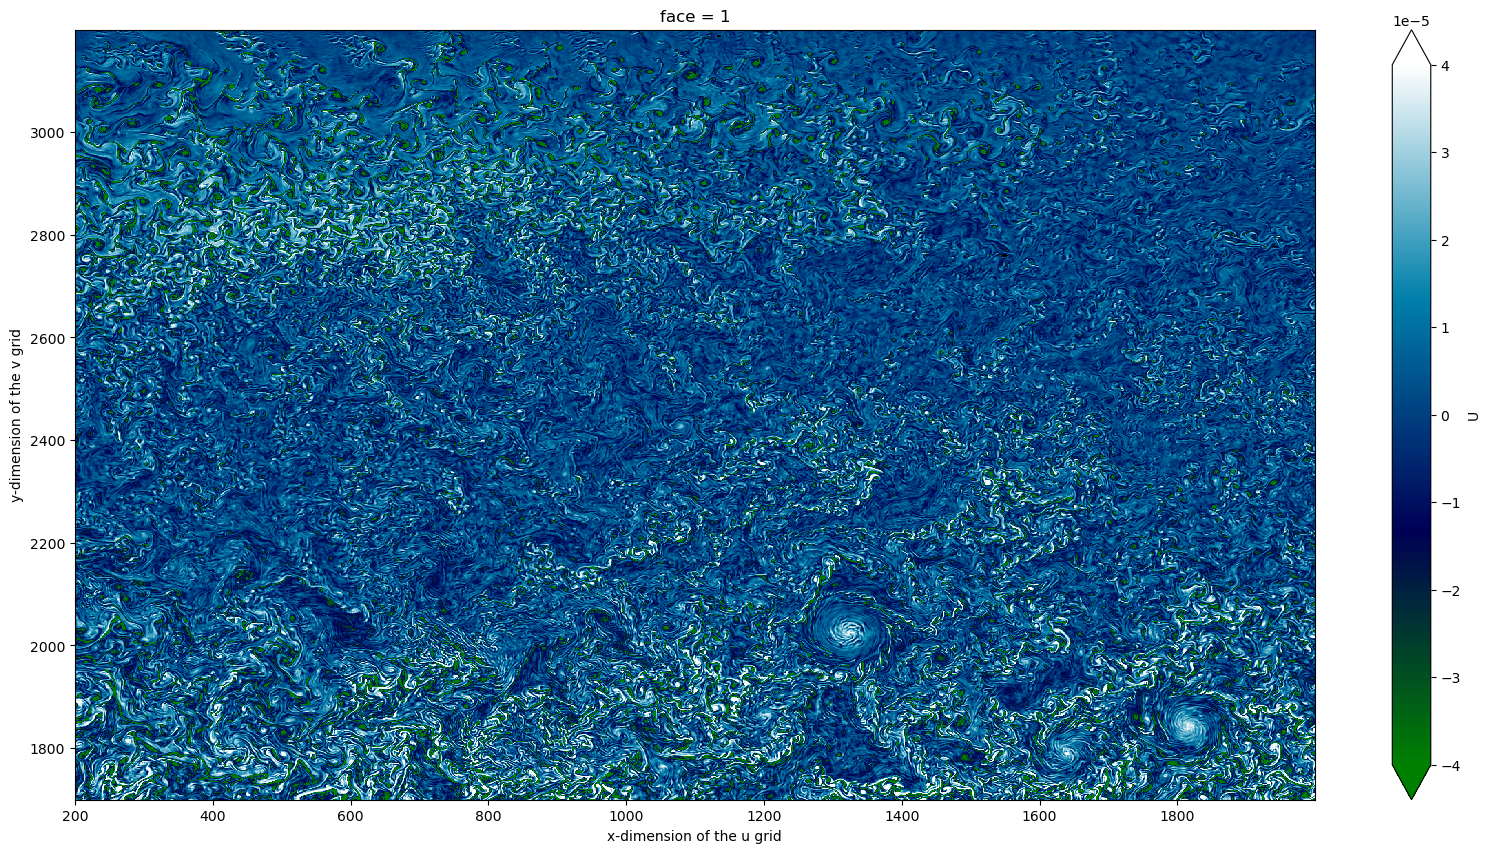

In [32]:
plt.figure(figsize=(20,10))
ζ_eq = ζ.isel(time=8500).sel(face=1).isel(j_g=slice(1700,3200)).isel(i_g=slice(200,2000)).rename({"i_g": "i", "j_g": "j"})
ζ_eq.plot.pcolormesh(vmax=0.00004,cmap='ocean')
plt.gca().set_facecolor('black')
plt.savefig('high_res_plot.png', dpi=300, bbox_inches='tight')

In [8]:
σ_eq = σ.isel(time=8500).sel(face=1).isel(j_g=j_eq).isel(i_g=i_eq).rename({"i_g": "i", "j_g": "j"})/1.3/10**-5
ζ_eq = ζ.isel(time=8500).sel(face=1).isel(j_g=j_eq).isel(i_g=i_eq).rename({"i_g": "i", "j_g": "j"})/1.3/10**-5#*np.sign(ds.sel(face=1).isel(j_g=j_extent).isel(i_g=i_extent).YG)
D_eq= D.isel(time=8500).sel(face=1).isel(j=j_eq).isel(i=i_eq)/10**-4
D_histrain_eq = D_eq.where((σ_eq>(ζ_eq+1))).load()


σ_sum = σ.isel(time=4500).sel(face=8).isel(j_g=j_sum).isel(i_g=i_sum).rename({"i_g": "i", "j_g": "j"})/5/10**-5
ζ_sum = ζ.isel(time=4500).sel(face=8).isel(j_g=j_sum).isel(i_g=i_sum).rename({"i_g": "i", "j_g": "j"})/-5/10**-5#*np.sign(ds.sel(face=1).isel(j_g=j_extent).isel(i_g=i_extent).YG)
D_sum = D.isel(time=4500).sel(face=8).isel(j=j_sum).isel(i=i_sum)/10**-4
D_histrain_sum = D_sum.where((σ_sum>(ζ_sum+1))).load()

σ_gs = σ.isel(time=8500).sel(face=10).isel(j_g=j_gs).isel(i_g=i_gs).rename({"i_g": "i", "j_g": "j"})/10**-4
ζ_gs = ζ.isel(time=8500).sel(face=10).isel(j_g=j_gs).isel(i_g=i_gs).rename({"i_g": "i", "j_g": "j"})/(-10**-4)#*np.sign(ds.sel(face=1).isel(j_g=j_extent).isel(i_g=i_extent).YG)
D_gs = D.isel(time=8500).sel(face=10).isel(j=j_gs).isel(i=i_gs)/10**-4
D_histrain_gs = D_gs.where((σ_gs>(ζ_gs+1))).load()

/tmp/ipykernel_83/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_83/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_83/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_83/2510200718.py:37: RuntimeWarning: invalid value encountered in divide
  v_diff_y = (v[..., 1:, :] - v[..., :-1, :]) / dyc[..., 1:, :]
/tmp/ipykernel_83/2510200718.py:34: RuntimeWarning: invalid value encountered in divide
  u_diff_x = (u[..., 1:] - u[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_83/2510200718.py:35: RuntimeWarning: invalid value encountered in divide
  v_diff_x = (v[..., 1:] - v[..., :-1]) / dxc[..., 1:]
/tmp/ipykernel_83/2510200718.py:36: RuntimeWarning: invalid value encountered in divide
  u_diff_y = (u[..., 1:, :] - u[...,

In [9]:
lon_eq = ds.sel(face=1).isel(j=j_eq).isel(i=i_eq).XC.mean('j')
lat_eq = ds.sel(face=1).isel(j=j_eq).isel(i=i_eq).YC.mean('i')

lon_sum = ds.sel(face=8).isel(j=j_sum).isel(i=i_sum).XC.mean('i')
lat_sum = ds.sel(face=8).isel(j=j_sum).isel(i=i_sum).YC.mean('j')

lon_gs = ds.sel(face=10).isel(j=j_gs).isel(i=i_gs).XC.mean('i')
lat_gs = ds.sel(face=10).isel(j=j_gs).isel(i=i_gs).YC.mean('j')

In [10]:
theta = ds.SST.isel(time=8500).sel(face=10).isel(j=j_gs).isel(i=i_gs)

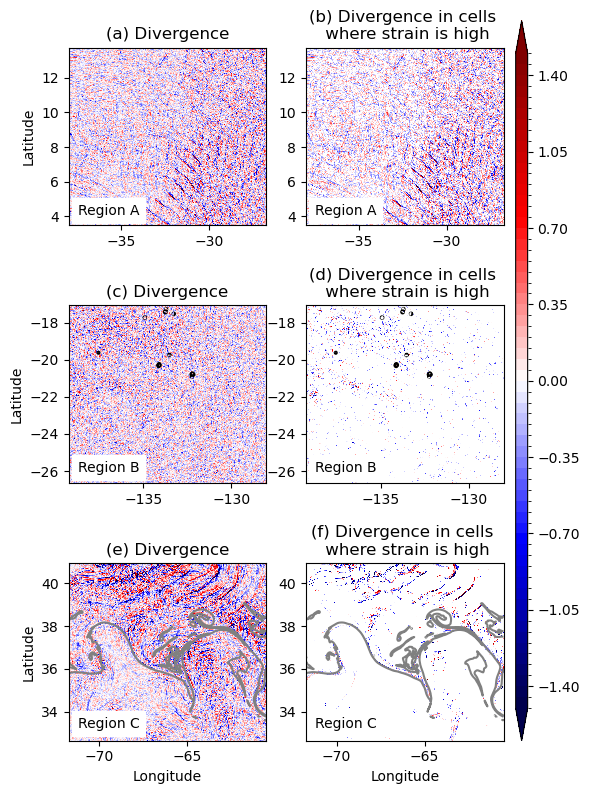

In [18]:
fig = plt.figure(figsize=(6,9))

levels=np.arange(-1.5,1.501,0.05)
cmap = plt.get_cmap('seismic')
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

plt.subplot(321)
plt.pcolormesh(lon_eq, lat_eq, D_eq.T,cmap='seismic',norm=norm,rasterized=True)

plt.title('(a) Divergence')
plt.xlabel('')
plt.ylabel('Latitude')
plt.text(lon_eq.min()+0.5,lat_eq.min()+0.6, 'Region A',backgroundcolor='w')

plt.subplot(322)
plt.pcolormesh(lon_eq, lat_eq, D_histrain_eq.T,cmap='seismic',norm=norm,rasterized=True)
plt.title('(b) Divergence in cells \n where strain is high')
plt.xlabel('')
plt.ylabel('')
plt.text(lon_eq.min()+0.5,lat_eq.min()+0.6, 'Region A',backgroundcolor='w')

plt.subplot(323)
plt.pcolormesh(lon_sum, lat_sum, D_sum.T,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_sum, lat_sum, depth_sum,colors='k',levels=[-50, 5],linewidths=3)
plt.title('(c) Divergence')
plt.xlabel('')
plt.ylabel('Latitude')

plt.text(lon_sum.min()+0.5,lat_sum.min()+0.6, 'Region B',backgroundcolor='w')

plt.subplot(324)
plt.pcolormesh(lon_sum, lat_sum, D_histrain_sum.T,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_sum, lat_sum, depth_sum,colors='k',levels=[-50, 5],linewidths=3)
plt.title('(d) Divergence in cells \n where strain is high')
plt.xlabel('')
plt.ylabel('')

plt.text(lon_sum.min()+0.5,lat_sum.min()+0.6, 'Region B',backgroundcolor='w')

plt.subplot(325)
plt.pcolormesh(lon_gs, lat_gs, D_gs.T,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_gs, lat_gs, theta.T,levels=[27, 40],colors='grey')
plt.title('(e) Divergence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.text(lon_gs.min()+0.5,lat_gs.min()+0.6, 'Region C',backgroundcolor='w')

plt.subplot(326)
cs=plt.pcolormesh(lon_gs, lat_gs, D_histrain_gs.T,cmap='seismic',norm=norm,rasterized=True)
plt.contour(lon_gs, lat_gs, theta.T,levels=[27, 40],colors='grey')
plt.title('(f) Divergence in cells \n where strain is high')
plt.xlabel('Longitude')
plt.ylabel('')

plt.text(lon_gs.min()+0.5,lat_gs.min()+0.6, 'Region C',backgroundcolor='w')

cbar_ax = fig.add_axes([0.87, 0.11, 0.02, 0.8])
fig.colorbar(cs, cax=cbar_ax,extend='both')

plt.subplots_adjust(right=0.85,hspace=0.45)

fig.savefig('case_study_snapshots.png')